# Diagnóstico e Validação de Modelos VARMAX

Neste notebook, vamos validar se o modelo ajustado é adequado.

## Objetivos:
- Analisar resíduos (white noise)
- Verificar autocorrelação dos erros
- Aplicar teste de Ljung-Box
- Testar normalidade dos resíduos

👉 Um bom modelo deve ter resíduos:
- Não correlacionados
- Média zero
- Variância constante
- Distribuição aproximadamente normal

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import normaltest

plt.style.use('dark_background')
np.random.seed(42)

In [4]:
n = 200

exog = np.random.normal(0, 1, n)
e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)

x = np.zeros(n)
y = np.zeros(n)

for t in range(1, n):
    x[t] = 0.6 * x[t-1] + 0.3 * exog[t] + e1[t]
    y[t] = 0.4 * y[t-1] + 0.2 * x[t-1] + 0.5 * exog[t] + e2[t]

df = pd.DataFrame({"X": x, "Y": y})
df_exog = pd.DataFrame({"Exog": exog})

modelo = VARMAX(df, exog=df_exog, order=(1,1))
resultado = modelo.fit(disp=False)

/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


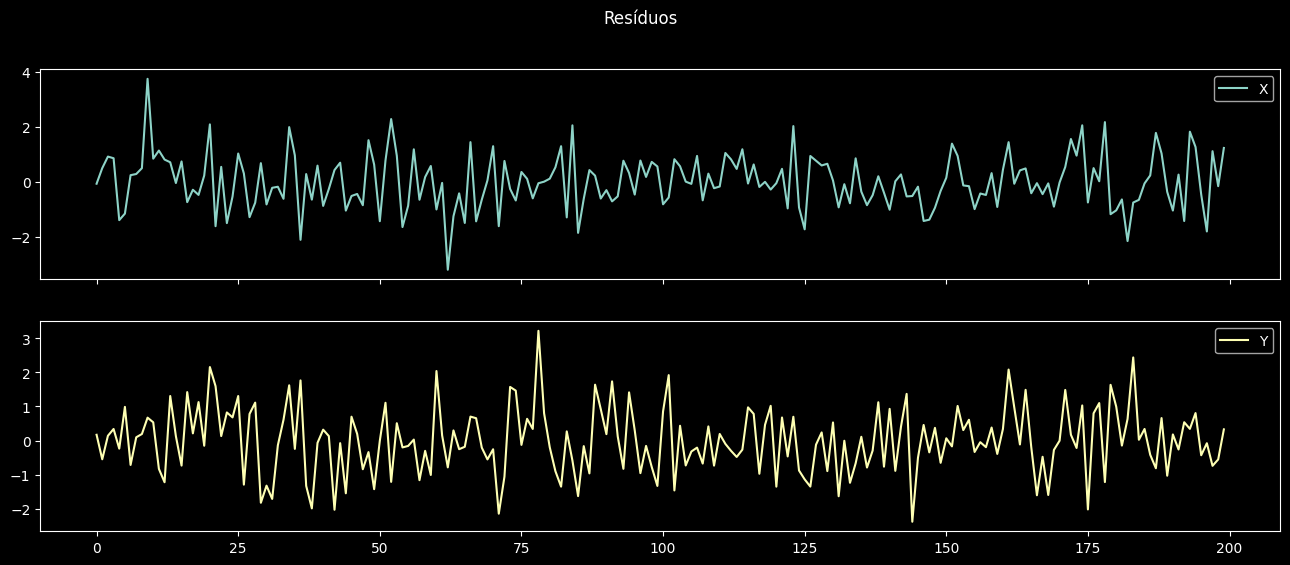

In [6]:
residuos = resultado.resid

residuos.plot(subplots=True, figsize=(16,6), title="Resíduos")
plt.show()

## White Noise

Resíduos ideais devem parecer ruído branco:
- Sem padrão
- Sem tendência
- Variância constante

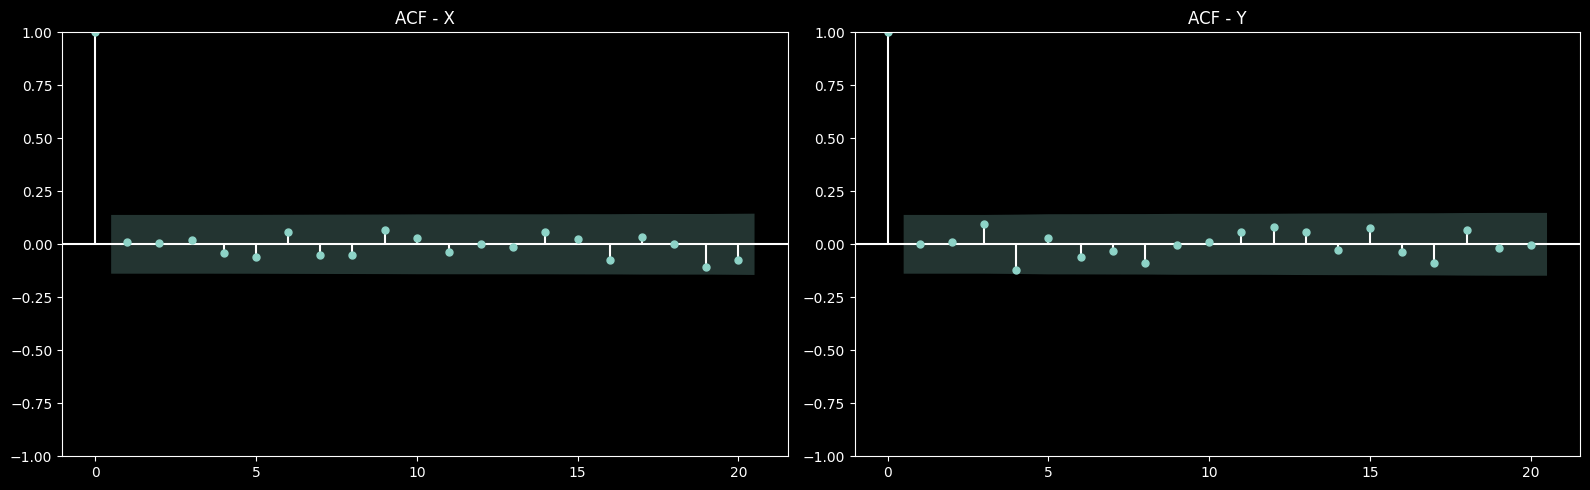

In [8]:
plt.figure(figsize=(16,5))

for i, col in enumerate(residuos.columns):
    plt.subplot(1, 2, i+1)
    plot_acf(residuos[col], lags=20, ax=plt.gca())
    plt.title(f"ACF - {col}")

plt.tight_layout()
plt.show()

In [9]:
for col in residuos.columns:
    print(f"\n--- Ljung-Box: {col} ---")
    lb = acorr_ljungbox(residuos[col], lags=[10], return_df=True)
    print(lb)


--- Ljung-Box: X ---
     lb_stat  lb_pvalue
10  4.125982   0.941485

--- Ljung-Box: Y ---
     lb_stat  lb_pvalue
10  7.774362   0.650866


## Interpretação

- H0: não há autocorrelação
- p-valor > 0.05 → OK (resíduos independentes)
- p-valor < 0.05 → problema no modelo

In [10]:
for col in residuos.columns:
    stat, p = normaltest(residuos[col])
    print(f"{col} → p-valor: {p:.4f}")

X → p-valor: 0.0646
Y → p-valor: 0.5438


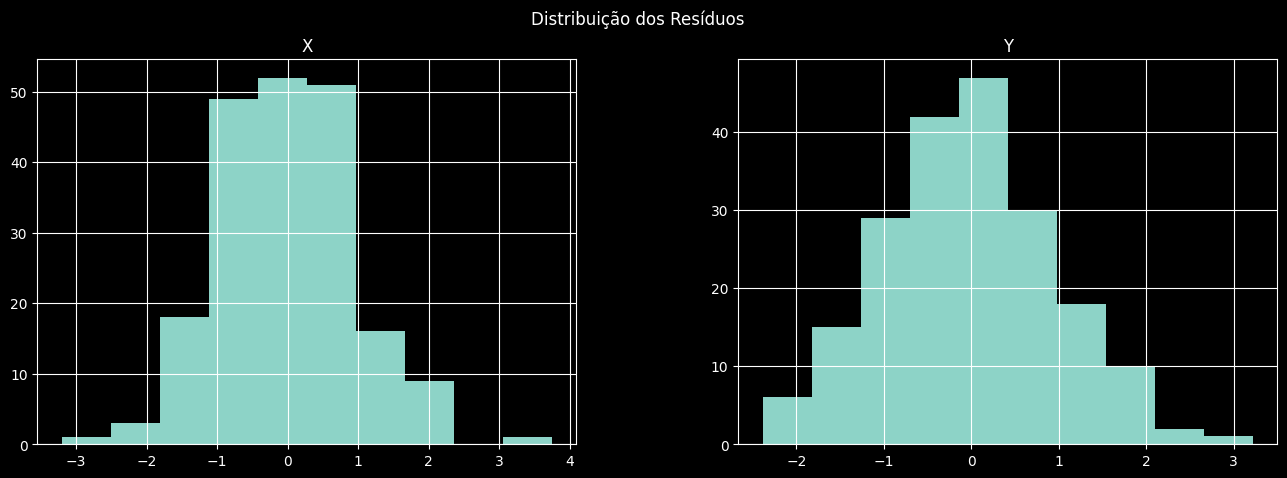

In [12]:
residuos.hist(figsize=(16,5))
plt.suptitle("Distribuição dos Resíduos")
plt.show()

## Conclusão

Checklist de um bom modelo:

✔ Resíduos sem padrão  
✔ Sem autocorrelação (Ljung-Box)  
✔ Aproximadamente normais  

Se falhar:
- Ajustar (p, q)
- Diferenciar dados
- Incluir/excluir variáveis exógenas